In [22]:
from libs.data_request import SigMFRepo
import cfg
log = cfg.set_logger()


import numpy as np
from scipy.signal import welch
import matplotlib.pyplot as plt

repo = SigMFRepo()
iq_to_download = [15]
log.info(f"Downloading IQ data for IQs: {iq_to_download}")
raw_iqs, meta_params = repo.get_iq_data(iq_to_download)

# 1. Print Metadata
for i, params in enumerate(meta_params): # Fixed typo here
    print(f"--- IQ {iq_to_download[i]} Parameters ---")
    print(f"Freq: {params.center_freq}")
    print(f"Sample Rate: {params.sample_rate}")
    print(f"LNA: {params.lna}")
    print(f"VGA: {params.vga}")

# 2. Convert to complex NumPy arrays outside the class
iq_arrays = [arr[0::2] + 1j * arr[1::2] for arr in raw_iqs]

[IPYKERNEL_LAUNCHER]INFO      Downloading IQ data for IQs: [15]
  ↳ IQ 15 loaded instantly from local cache
--- IQ 15 Parameters ---
Freq: 98000000
Sample Rate: 20000000
LNA: 16
VGA: 16


In [23]:
# 3. Print Array Metrics
for i, arr in enumerate(iq_arrays):
    print(f"--- Array {iq_to_download[i]} Metrics ---")
    print(f"Length: {len(arr)}")
    print(f"Type: {arr.dtype}")
    
    print(f"Min: {np.min(arr.real)} + {np.min(arr.imag)}j")
    print(f"Max: {np.max(arr.real)} + {np.max(arr.imag)}j")
    print(f"Mean: {np.mean(arr)}")
    print(f"Median: {np.median(arr.real)} + {np.median(arr.imag)}j")
    print(f"Std (Magnitude): {np.std(arr)}")
    
    # Covariance and Correlation between I (real) and Q (imaginary)
    cov_matrix = np.cov(arr.real, arr.imag)
    corr_matrix = np.corrcoef(arr.real, arr.imag)
    
    print(f"Covariance (I vs Q): {cov_matrix[0, 1]:.4f}")
    print(f"Correlation (I vs Q): {corr_matrix[0, 1]:.4f}\n")

--- Array 15 Metrics ---
Length: 26214400
Type: complex128
Min: -16.0 + -17.0j
Max: 22.0 + 22.0j
Mean: (3.3565975189208985+2.3470223236083987j)
Median: 3.0 + 2.0j
Std (Magnitude): 6.890888052703617
Covariance (I vs Q): -0.4794
Correlation (I vs Q): -0.0202



[IPYKERNEL_LAUNCHER]INFO      
[IPYKERNEL_LAUNCHER]INFO      ================================================================
[IPYKERNEL_LAUNCHER]INFO       Processing File: 15
[IPYKERNEL_LAUNCHER]INFO       Sample Rate: 20.00 MHz | Total Samples: 26214400
[IPYKERNEL_LAUNCHER]INFO      ================================================================
[IPYKERNEL_LAUNCHER]INFO      Cut Size | Samples    | MSE (dB^2)   | MAE (dB)  
[IPYKERNEL_LAUNCHER]INFO      ----------------------------------------------------------------
[IPYKERNEL_LAUNCHER]INFO      Full     | 26214400   | 0.0000       | 0.0000    
[IPYKERNEL_LAUNCHER]INFO      1/2      | 13107200   | 0.2283       | 0.2037    
[IPYKERNEL_LAUNCHER]INFO      1/4      | 6553600    | 0.6470       | 0.3583    
[IPYKERNEL_LAUNCHER]INFO      1/8      | 3276800    | 1.0636       | 0.4912    
[IPYKERNEL_LAUNCHER]INFO      1/16     | 1638400    | 2.6536       | 0.7024    
[IPYKERNEL_LAUNCHER]INFO      1/32     | 819200     | 3.7515       | 0.91

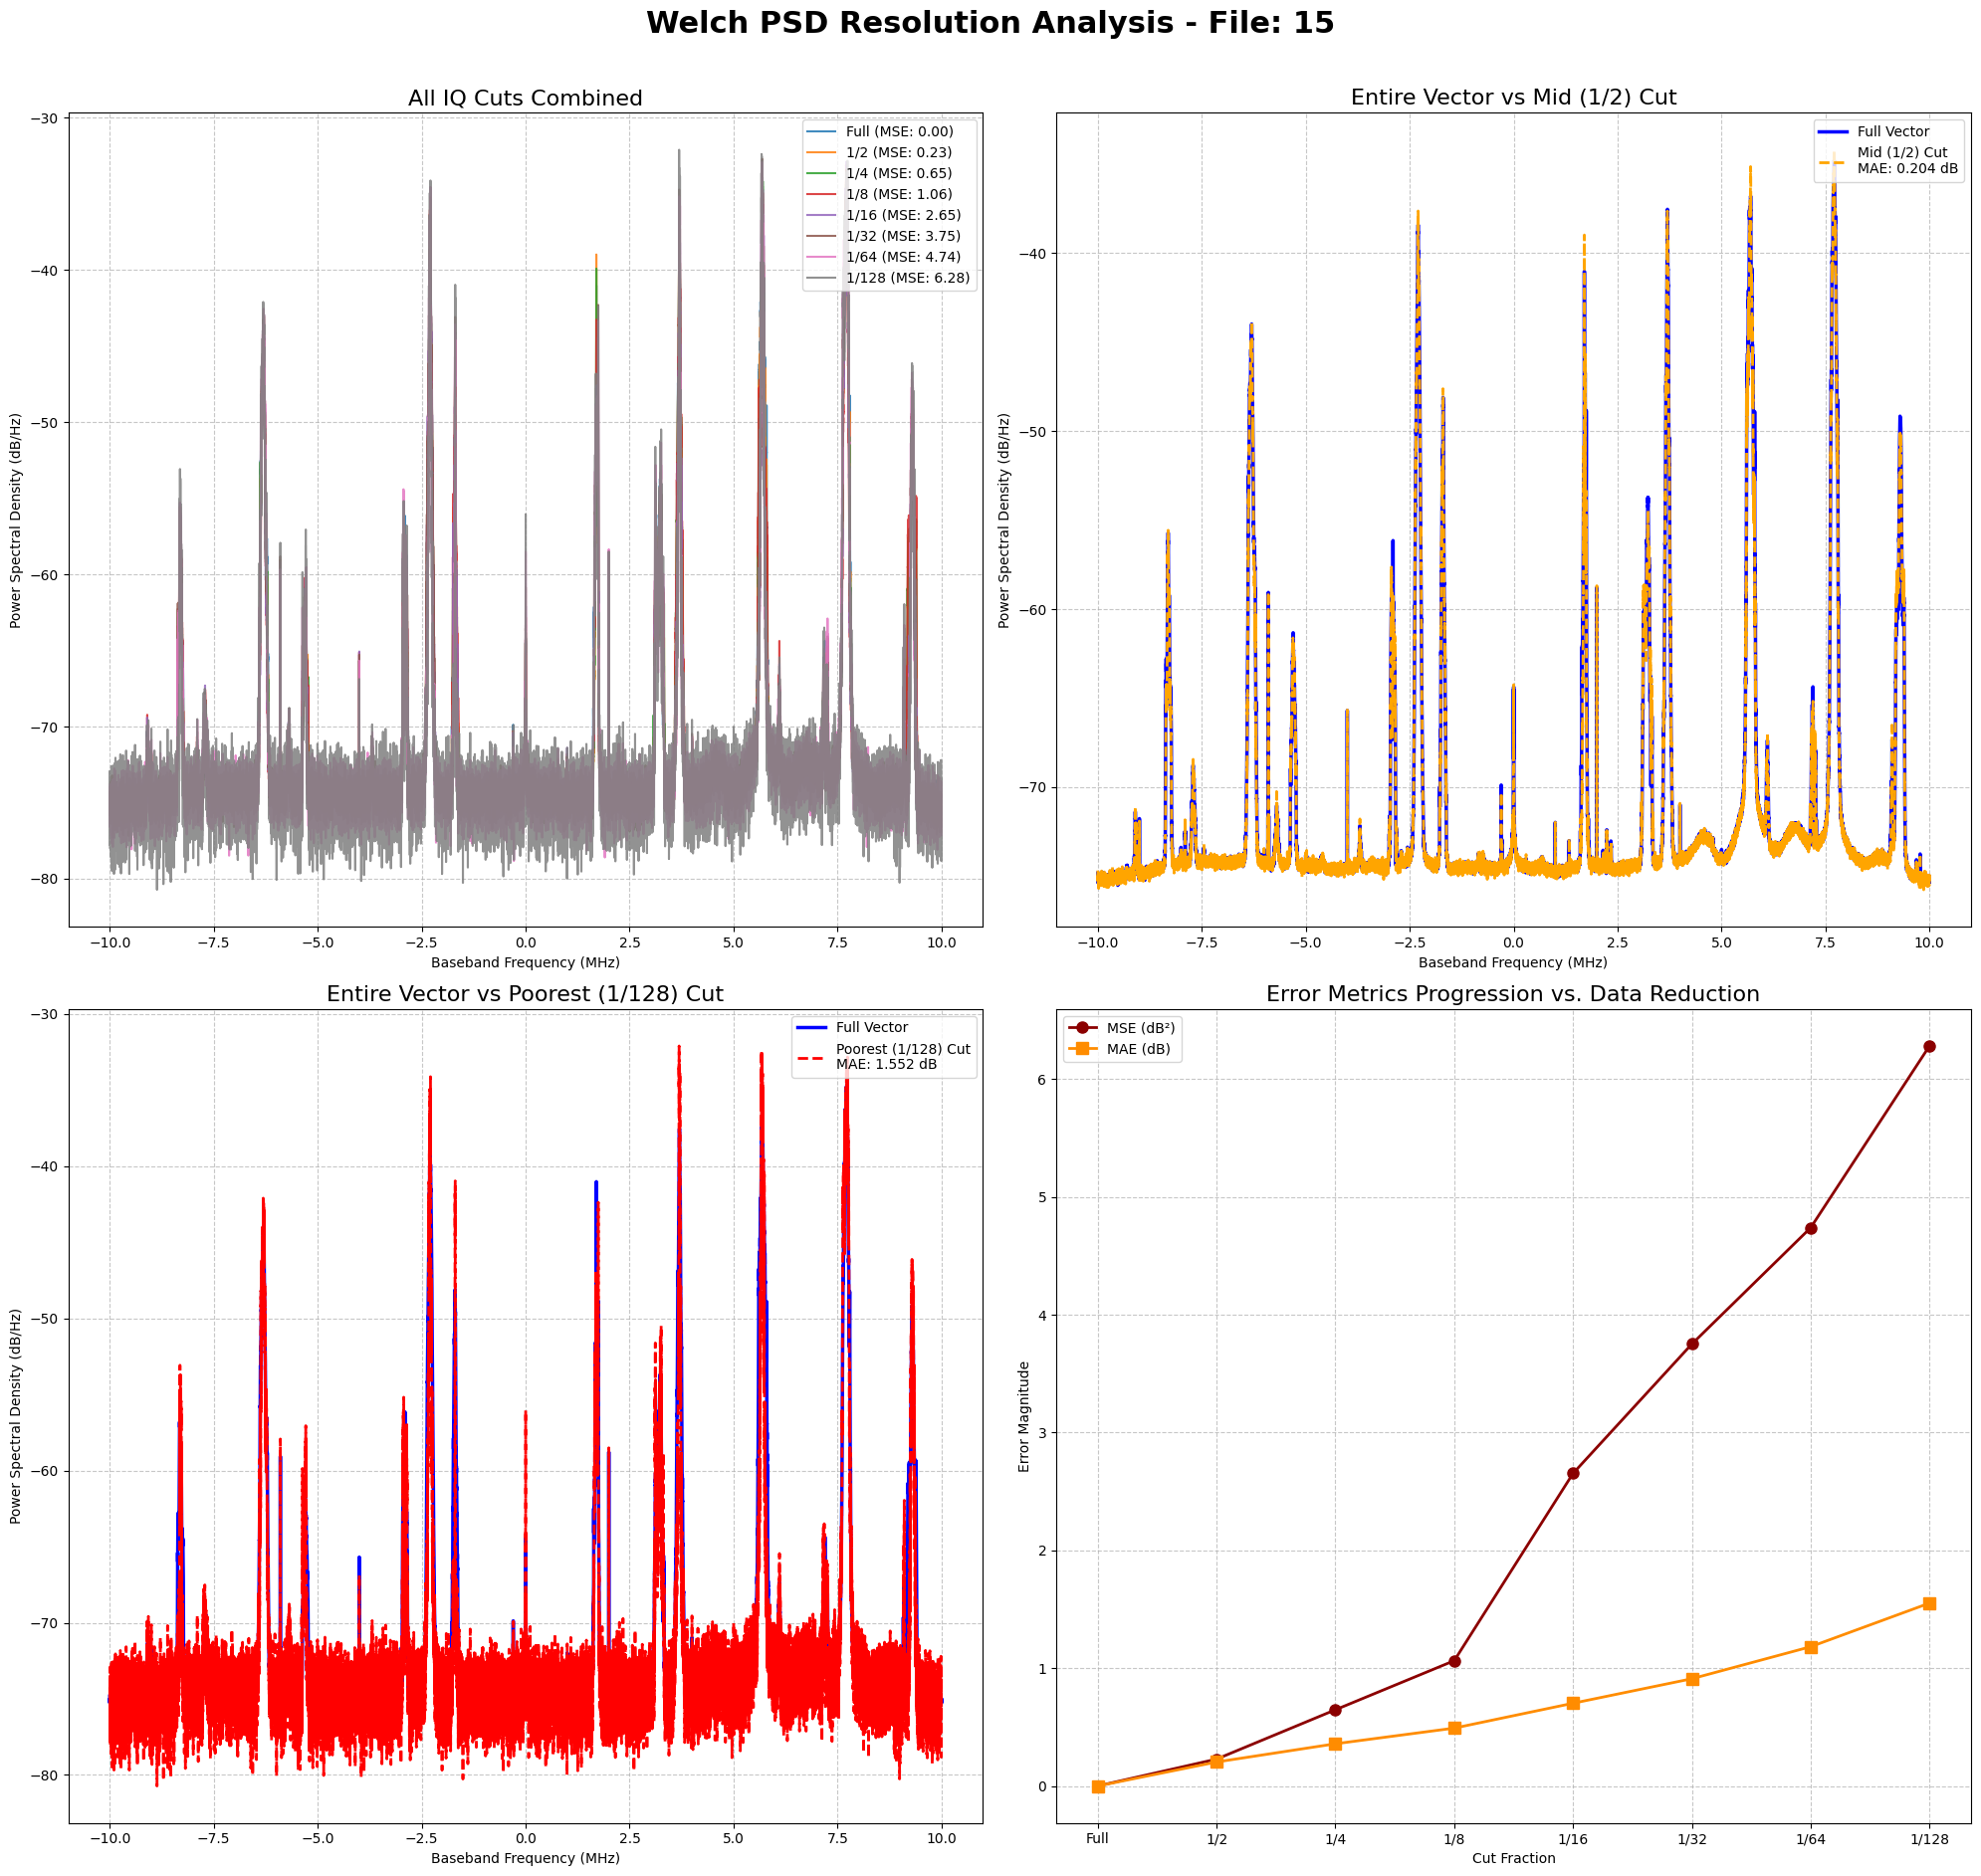

In [24]:
# Extract the single IQ array and its metadata directly
iq_signal = iq_arrays[0]
file_name = iq_to_download[0]
fs = meta_params[0].sample_rate
length_iq = len(iq_signal)

# Define our fractions and compute the exact cut lengths
fractions = [1, 2, 4, 8, 16, 32, 64, 128]
fraction_labels = ['Full', '1/2', '1/4', '1/8', '1/16', '1/32', '1/64', '1/128']
iq_cuts = [length_iq // f for f in fractions]

# Pre-calculate the "Ground Truth" (Full Array) to compute MSE/MAE against
f_full, Pxx_full = welch(iq_signal, fs=fs, nperseg=32768, noverlap=32768//2, nfft=32768, return_onesided=False)
f_shifted_mhz = np.fft.fftshift(f_full) / 1e6  # Shift and convert to MHz once
Pxx_db_full = 10 * np.log10(np.fft.fftshift(Pxx_full))

# Storage for this file's metrics and traces
Pxx_db_list = []
mse_list = []
mae_list = []

# Better, highly readable console output
log.info(f"")
log.info(f"================================================================")
log.info(f" Processing File: {file_name}")
log.info(f" Sample Rate: {fs/1e6:.2f} MHz | Total Samples: {length_iq}")
log.info(f"================================================================")
log.info(f"{'Cut Size':<8} | {'Samples':<10} | {'MSE (dB^2)':<12} | {'MAE (dB)':<10}")
log.info(f"----------------------------------------------------------------")

for idx, iq_cut in enumerate(iq_cuts):
    # Safety check: welch needs length >= nperseg to output exactly 32768 points
    if iq_cut < 32768:
        log.warning(f"Cut {fraction_labels[idx]} ({iq_cut} pts) is smaller than nperseg (32768). Errors may occur.")
        
    # Calculate PSD for the current cut
    f, Pxx = welch(iq_signal[:iq_cut], fs=fs, nperseg=32768, noverlap=32768//2, nfft=32768, return_onesided=False)
    Pxx_db = 10 * np.log10(np.fft.fftshift(Pxx))
    Pxx_db_list.append(Pxx_db)
    
    # Calculate Error Metrics (comparing current cut vs full length)
    mse = np.mean((Pxx_db_full - Pxx_db)**2)
    mae = np.mean(np.abs(Pxx_db_full - Pxx_db))
    
    mse_list.append(mse)
    mae_list.append(mae)
    
    # Print tabular data
    log.info(f"{fraction_labels[idx]:<8} | {iq_cut:<10} | {mse:<12.4f} | {mae:<10.4f}")
    
# --------------------------------------------------------------------
# Plotting Section (20x20 Figure, 2x2 Grid)
# --------------------------------------------------------------------
fig, axs = plt.subplots(2, 2, figsize=(20, 20))
fig.suptitle(f"Welch PSD Resolution Analysis - File: {file_name}", fontsize=22, fontweight='bold', y=0.94)

# 1. Top-Left: All Traces Plot
for idx, Pxx_db in enumerate(Pxx_db_list):
    axs[0, 0].plot(f_shifted_mhz, Pxx_db, label=f"{fraction_labels[idx]} (MSE: {mse_list[idx]:.2f})", alpha=0.85)
axs[0, 0].set_title("All IQ Cuts Combined", fontsize=16)
axs[0, 0].legend(loc='upper right')

# 2. Top-Right: Full vs Mid (1/2) Cut
axs[0, 1].plot(f_shifted_mhz, Pxx_db_full, label="Full Vector", linewidth=2.5, color='blue')
axs[0, 1].plot(f_shifted_mhz, Pxx_db_list[1], label=f"Mid (1/2) Cut\nMAE: {mae_list[1]:.3f} dB", linestyle='--', linewidth=2, color='orange')
axs[0, 1].set_title("Entire Vector vs Mid (1/2) Cut", fontsize=16)
axs[0, 1].legend(loc='upper right')

# 3. Bottom-Left: Full vs Poorest Cut
poorest_label = fraction_labels[-1]
axs[1, 0].plot(f_shifted_mhz, Pxx_db_full, label="Full Vector", linewidth=2.5, color='blue')
axs[1, 0].plot(f_shifted_mhz, Pxx_db_list[-1], label=f"Poorest ({poorest_label}) Cut\nMAE: {mae_list[-1]:.3f} dB", linestyle='--', linewidth=2, color='red')
axs[1, 0].set_title(f"Entire Vector vs Poorest ({poorest_label}) Cut", fontsize=16)
axs[1, 0].legend(loc='upper right')

# 4. Bottom-Right: Error Metrics Trend
ax4 = axs[1, 1]
ax4.plot(fractions, mse_list, marker='o', markersize=8, linewidth=2, label='MSE (dB²)', color='darkred')
ax4.plot(fractions, mae_list, marker='s', markersize=8, linewidth=2, label='MAE (dB)', color='darkorange')
ax4.set_title("Error Metrics Progression vs. Data Reduction", fontsize=16)
ax4.set_xscale('log', base=2) # Base 2 log scale matches your fractions beautifully
ax4.set_xticks(fractions)
ax4.set_xticklabels(fraction_labels)
ax4.set_xlabel("Cut Fraction")
ax4.set_ylabel("Error Magnitude")
ax4.legend(loc='upper left')

# Apply common formatting to all subplots
for ax in axs.flat:
    if ax != ax4: # Don't overwrite the bottom-right x-axis
        ax.set_xlabel("Baseband Frequency (MHz)")
        ax.set_ylabel("Power Spectral Density (dB/Hz)")
    ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.93]) # Adjust layout to not clip the main title
plt.show()